##  Second Model [gradient boosted trees]

LightGBM was created by Microsoft Research and it is an implementation of gradient boosted trees, aiming to have very fast performance.

In [ ]:
gbc = lgb.LGBMClassifier(
    boosting_type='gbdt',
    n_estimators=500,
    max_depth=1,
    learning_rate=0.05,
    device='gpu',             # Enable GPU
    gpu_platform_id=0,        # Use 0 if only one GPU
    gpu_device_id=0,
    random_state=42
)

gbc.fit(X_resampled, y_resampled)

In [ ]:
importances = pd.Series(gbc.feature_importances_, index=X_resampled.columns)
selected_features = importances[importances > 0].index.tolist()
X_selected = X_resampled[selected_features]

In [ ]:
def reduce_vif(X, threshold=10):
    while True:
        vif = pd.DataFrame()
        vif['feature'] = X.columns
        vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
        max_vif = vif['VIF'].max()
        if max_vif > threshold:
            feature_to_drop = vif.sort_values('VIF', ascending=False)['feature'].iloc[0]
            X = X.drop(columns=feature_to_drop)
        else:
            break
    return X

X_final = reduce_vif(X_selected)

In [ ]:
# X_final.to_csv('X_final_GDB.csv', index=False)  # index=False avoids saving row numbers

In [ ]:
X_final = pd.read_csv("X_final_GDB.csv")

In [ ]:
GB2X_train, GB2X_test, GB2y_train, GB2y_test = train_test_split(X_final, y_resampled, test_size=0.2, shuffle=False)

final_model = lgb.LGBMClassifier(
    boosting_type='gbdt',
    n_estimators=500,
    max_depth=1,
    learning_rate=0.05,
    device='gpu',             # Enable GPU
    gpu_platform_id=0,        # Use 0 if only one GPU
    gpu_device_id=0,
    random_state=42
)

final_model.fit(GB2X_train, GB2y_train)

In [ ]:
GB2y_pred = final_model.predict(GB2X_test)
GB2y_proba = final_model.predict_proba(GB2X_test)[:, 1]

### Evaluation

Accuracy: 0.9215482827145948
Precision: 1.0
Recall: 0.9215482827145948
F1 Score: 0.9591726536402324
ROC AUC: nan

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.92      0.96    113726

    accuracy                           0.92    113726
   macro avg       0.50      0.46      0.48    113726
weighted avg       1.00      0.92      0.96    113726



/home/bouda/miniforge3/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/bouda/miniforge3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/bouda/miniforge3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/bouda/miniforge3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set

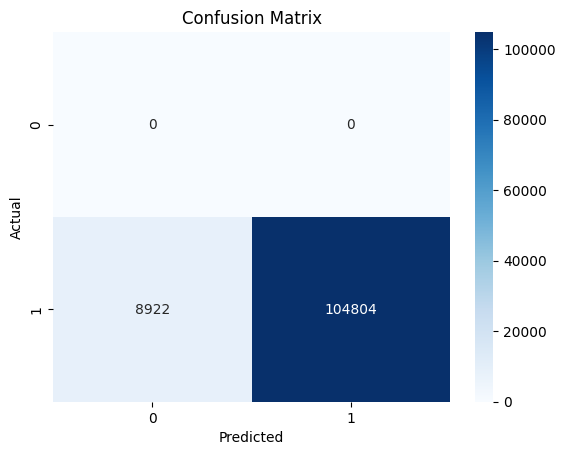

In [ ]:


# Basic scores
print("Accuracy:", accuracy_score(GB2y_test, GB2y_pred))
print("Precision:", precision_score(GB2y_test, GB2y_pred))
print("Recall:", recall_score(GB2y_test, GB2y_pred))
print("F1 Score:", f1_score(GB2y_test, GB2y_pred))
print("ROC AUC:", roc_auc_score(GB2y_test, GB2y_proba))

# Classification report
print("\nClassification Report:\n", classification_report(GB2y_test, GB2y_pred))

# Confusion matrix
conf_matrix = confusion_matrix(GB2y_test, GB2y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Explaination

#### Shap

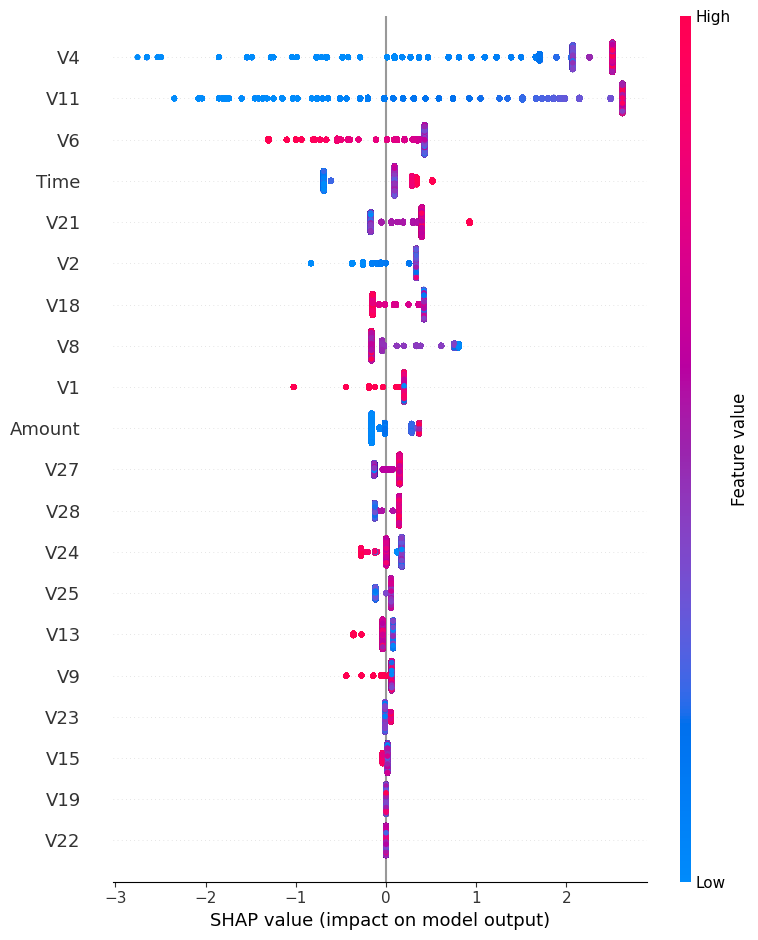

In [ ]:

explainer = shap.Explainer(final_model)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)


#### Lime

In [ ]:
explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    class_names=['Negative', 'Positive'],
    mode='classification'
)

In [ ]:
i = 0
exp = explainer.explain_instance(X_test.iloc[i].values, final_model.predict_proba, num_features=10)


In [ ]:
with open('lime_explanation.html', 'w') as f:
    f.write(exp.as_html())

#### lofo

[LightGBM] [Info] Number of positive: 136471, number of negative: 227452
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 5100
[LightGBM] [Info] Number of data points in the train set: 363923, number of used features: 20
[LightGBM] [Info] Using requested OpenCL platform 0 device 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 20 dense feature groups (6.94 MB) transferred to GPU in 0.007658 secs. 0 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.375000 -> initscore=-0.510827
[LightGBM] [Info] Start training from score -0.510827
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

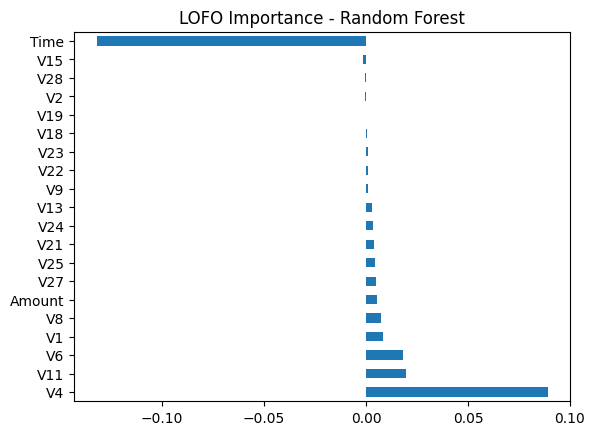

In [ ]:


baseline = cross_val_score(final_model, X_train, y_train, cv=5).mean()

lofo_scores = {}
for col in X_train.columns:
    X_lofo = X_train.drop(columns=[col])
    score = cross_val_score(final_model, X_lofo, y_train, cv=5).mean()
    lofo_scores[col] = baseline - score

lofo_df = pd.Series(lofo_scores).sort_values(ascending=False)
lofo_df.plot(kind='barh')
plt.title("LOFO Importance - Random Forest")
plt.show()

#### ICE

ValueError: All entries of features must be less than len(feature_names) = 20, got 20.

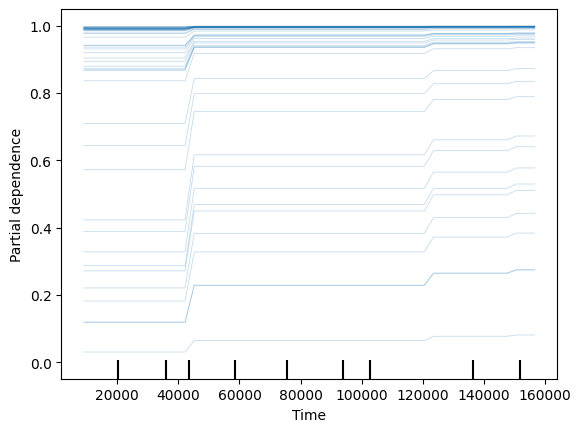

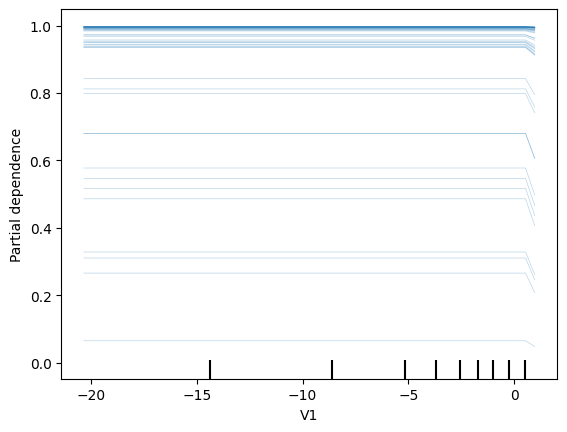

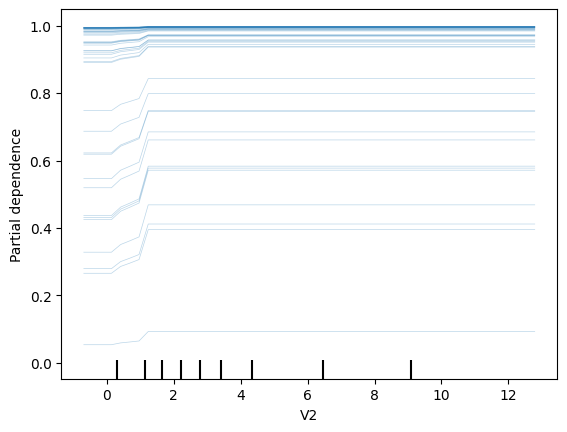

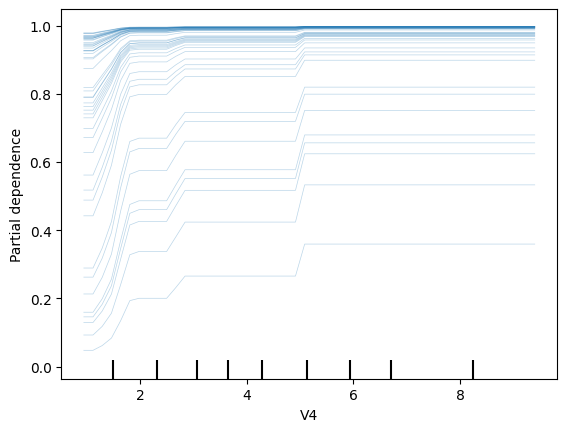

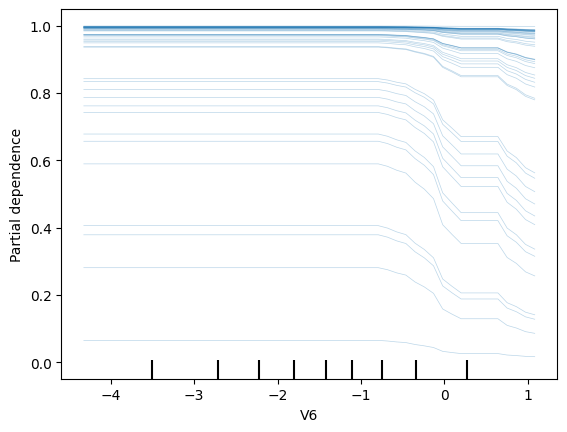

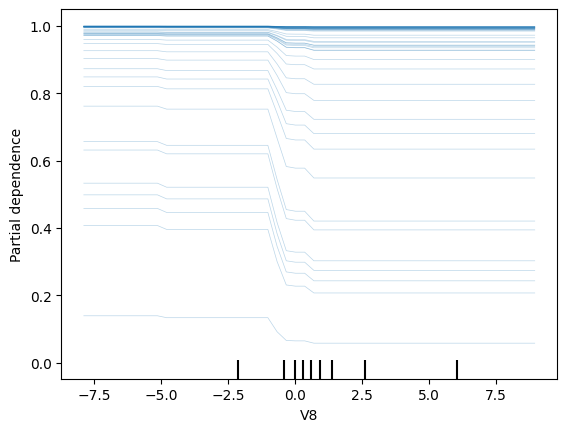

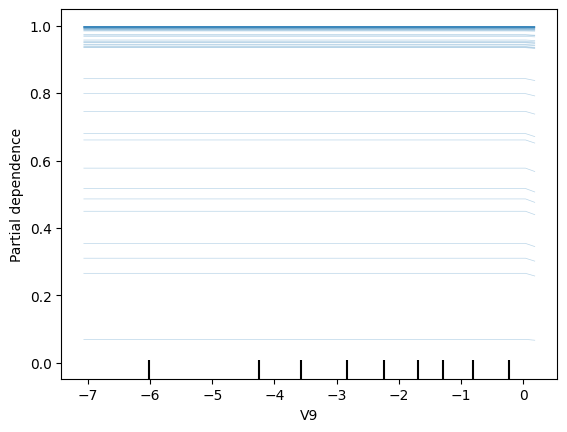

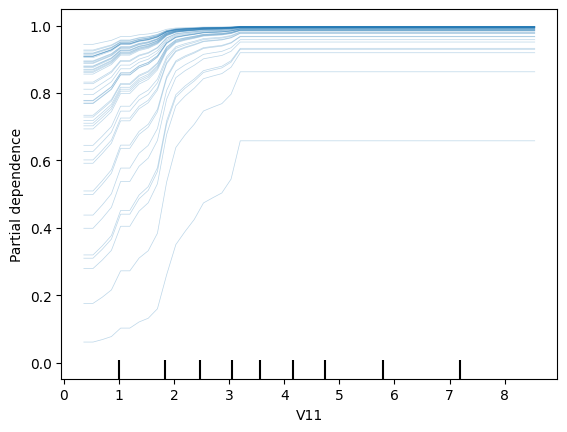

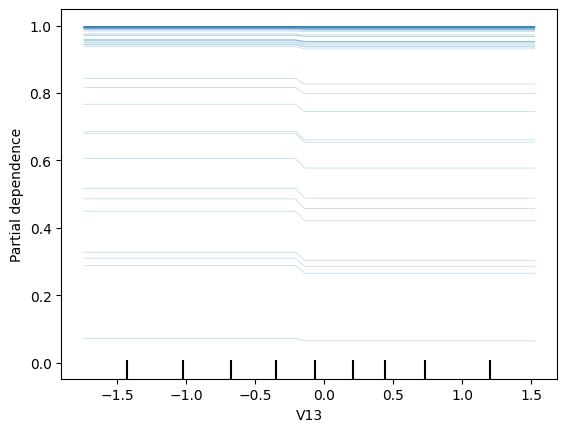

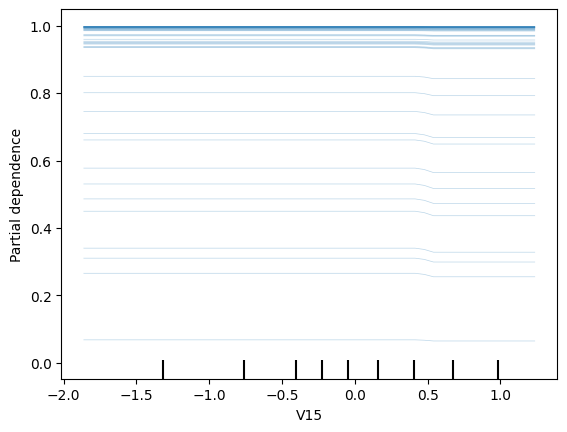

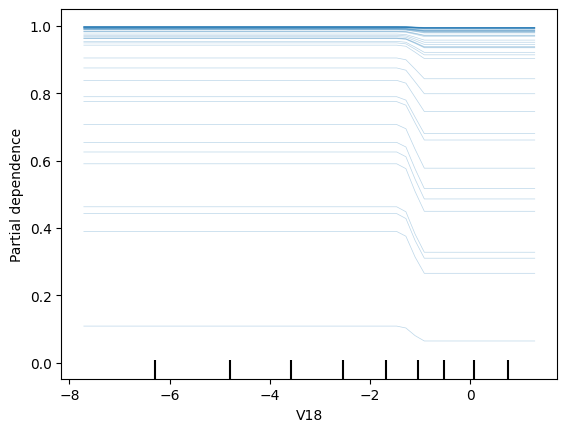

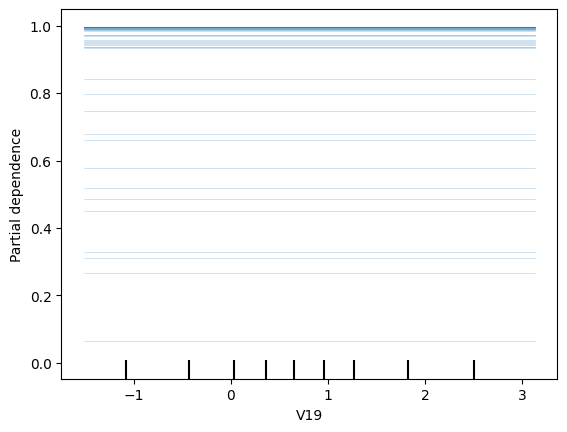

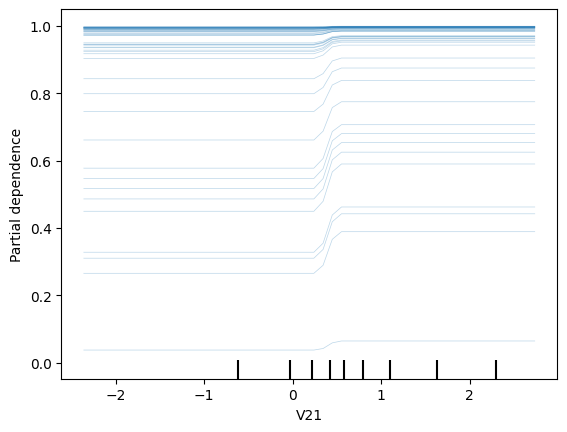

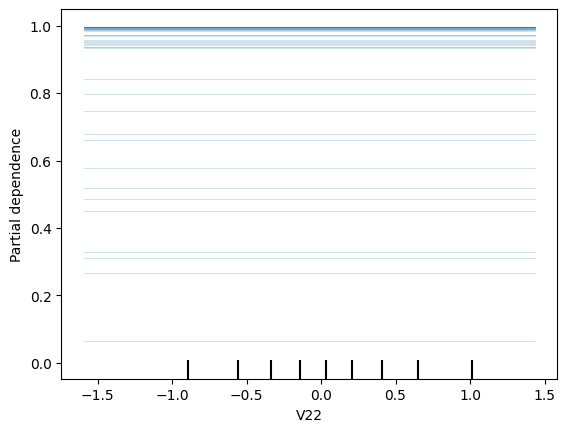

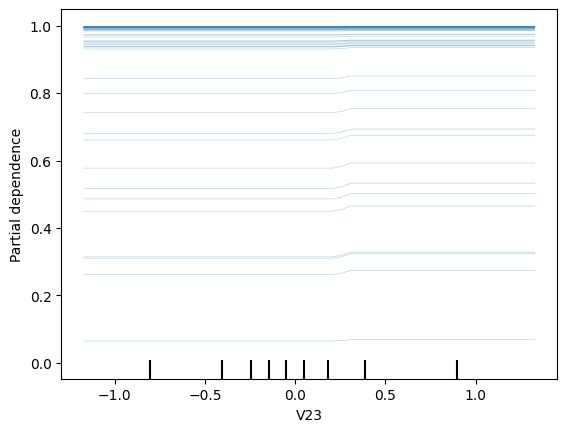

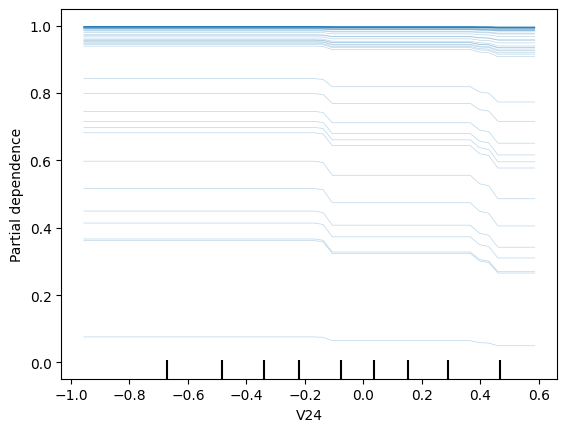

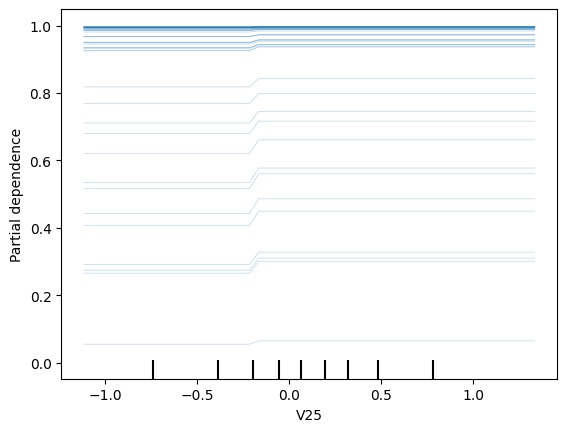

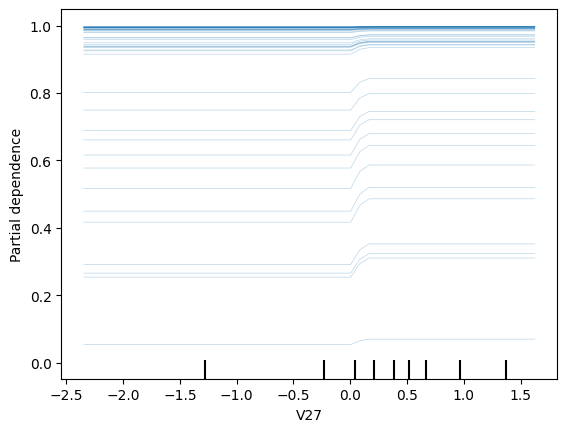

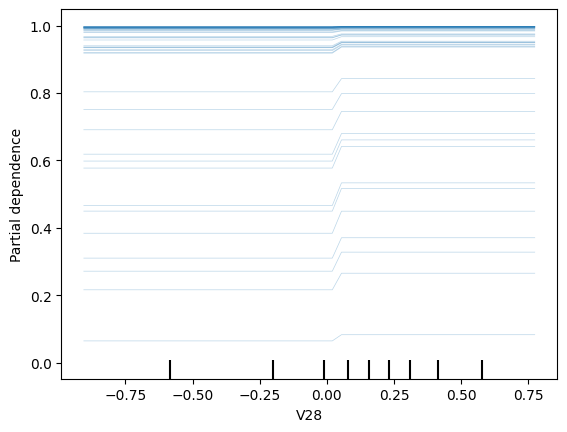

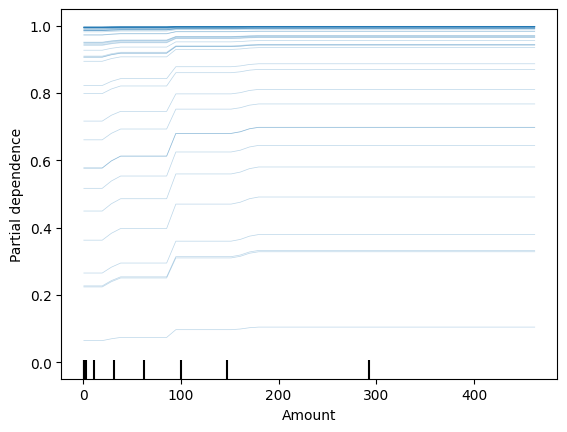

In [ ]:



for i in range(len(X_test)):
    PartialDependenceDisplay.from_estimator(
        estimator=final_model,
        X=X_test,
        features=[i],
        kind = "individual",
        grid_resolution=50,
        subsample=50,
        random_state=42
    )